In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import pickle

In [2]:
# General info
path_arrays = "/g/data/up6/ai2733/Gusts_downdrafts/data/arrays/"
path_figs   = "/g/data/up6/ai2733/Gusts_downdrafts/figures/Figures/"

lat_lon_cases = {"CASE1": (-29.49, 149.85), 
                "CASE2_new": (-35.16, 147.46), 
                 "CASE3_new": (-31.07,150.84)}
name_cases    = {"CASE1": "Moree Aero",
                 "CASE2_new": "Wagga Wagga", 
                 "CASE3_new": "Tamworth Airport"}


## Read mean profiles

In [3]:
cases = ["CASE1", "CASE2_new", "CASE3_new"]
domains = ["d02", "d03"]

In [4]:
# Coarsen grid 80 km from AWS
vars_read = ["pressure", "height"]
prof_coarsen_all = {stage: {} for stage in ["All"]}
for case in cases:
    for dom in domains:
        for var in vars_read:
            key = f"{var}_{case}_{dom}"
            file_coar = f'{path_arrays}TimeProf_{case}_{dom}_{var}_80kmAWS_coarsen.npy' 
            time_prof_coarsen_all = np.load(file_coar)
            prof_coarsen_all["All"][key] = time_prof_coarsen_all.mean(axis = 0)

## Read arrays of vertical velocity (filtered)

In [5]:
# Read arrays of vertical velocity (filtered)
read_w = True
thr = 5
if read_w:
    prefix = f'new{int(thr)}_'
    wa_down_strongest_below, wa_down_strongest_above = {},  {}
    wa_up_strongest_below, wa_up_strongest_above = {},  {}

    # Merge coarsen
    for case in cases:
        for dom in domains:
            key = f"{case}_{dom}_coarsen"
            # Load W
            with open(f"{path_arrays}/{prefix}wa_down_strongest_below_{case}_{dom}coarsen.pkl", "rb") as f: wa_down_strongest_below[key] = pickle.load(f)
            with open(f"{path_arrays}/{prefix}wa_down_strongest_above_{case}_{dom}coarsen.pkl", "rb") as f: wa_down_strongest_above[key] = pickle.load(f)
            with open(f"{path_arrays}/{prefix}wa_up_strongest_below_{case}_{dom}coarsen.pkl", "rb") as f: wa_up_strongest_below[key] = pickle.load(f)
            with open(f"{path_arrays}/{prefix}wa_up_strongest_above_{case}_{dom}coarsen.pkl", "rb") as f: wa_up_strongest_above[key] = pickle.load(f)

In [6]:
# Merge below and above FL
wa_down_strongest_all = {}
wa_up_strongest_all    = {}
for key in wa_down_strongest_below.keys():
    wa_down_strongest_all[key] = {}
    wa_up_strongest_all[key]   = {}
    for key2 in wa_down_strongest_below[key].keys():
         wa_down_strongest_all[key][key2] = np.where(~np.isnan(wa_down_strongest_below[key][key2]),  wa_down_strongest_below[key][key2], wa_down_strongest_above[key][key2])
         wa_up_strongest_all[key][key2]   = np.where(~np.isnan(wa_up_strongest_below[key][key2]),    wa_up_strongest_below[key][key2],   wa_up_strongest_above[key][key2])

In [7]:
# Total counts with different thresholds: Updrafts 
counts_all_up_below = {}
counts_all_up_above = {}
counts_all_up_all   = {}
for thr in [5.0, 8.0, 12.0]: #, -15.0]:
    counts_all_up_below[thr] = {}
    counts_all_up_above[thr] = {}
    counts_all_up_all[thr] = {}
    for key in wa_up_strongest_above.keys():
        counts_all_up_below[thr][key] = {}
        counts_all_up_above[thr][key] = {}
        counts_all_up_all[thr][key]   = {}
        for key2 in wa_up_strongest_above[key].keys():
            arr = wa_up_strongest_below[key][key2]
            mask = (arr >= thr) & (~np.isnan(arr))
            counts_all_up_below[thr][key][key2] = np.count_nonzero(mask)

            arr = wa_up_strongest_above[key][key2]
            mask = (arr >= thr) & (~np.isnan(arr))
            counts_all_up_above[thr][key][key2] = np.count_nonzero(mask)

            arr = wa_up_strongest_all[key][key2]
            mask = (arr >= thr) & (~np.isnan(arr))
            counts_all_up_all[thr][key][key2] = np.count_nonzero(mask)
             

In [8]:
# Total counts with different thresholds: downdrafts 
counts_all_down_below = {}
counts_all_down_above = {}
counts_all_down_all   = {}
for thr in [-5.0, -8.0, -12.0]: #, -15.0]:
    counts_all_down_below[thr] = {}
    counts_all_down_above[thr] = {}
    counts_all_down_all[thr] = {}
    for key in wa_down_strongest_above.keys():
        counts_all_down_below[thr][key] = {}
        counts_all_down_above[thr][key] = {}
        counts_all_down_all[thr][key]   = {}
        for key2 in wa_down_strongest_above[key].keys():
            arr = wa_down_strongest_below[key][key2]
            mask = (arr <= thr) & (~np.isnan(arr))
            counts_all_down_below[thr][key][key2] = np.count_nonzero(mask)

            arr = wa_down_strongest_above[key][key2]
            mask = (arr <= thr) & (~np.isnan(arr))
            counts_all_down_above[thr][key][key2] = np.count_nonzero(mask)

            arr = wa_down_strongest_all[key][key2]
            mask = (arr <= thr) & (~np.isnan(arr))
            counts_all_down_all[thr][key][key2] = np.count_nonzero(mask)
             

## Read arrays of different variables

In [9]:
# Read arrays of different variables 
vars_read = ["WSPD10MAX", "REFD_MAX", "QRAIN","QGRAUP", "RAINNC"]
how_read  = ["All", "All", "sum", "sum", "All"]
fl_read = [None ,None,None,None,None,]

var_coarsen_all  = {}
for case in cases:
    for dom in domains:
        for var, how, flevel in zip (vars_read,how_read,fl_read):
            key = f"{var}_{how}_{case}_{dom}_{flevel}"

            # Coarsen grid 80 km from AWS
            file_coar = f'{path_arrays}/{case}_{dom}_{var}{how}_80kmAWS_coarsen.npy' if flevel == None else f'/g/data/w28/ai2733/arrays/{case}_{dom}_{var}{how}_80kmAWS_coarsen_{flevel}flevel.npy'
            var_coarsen_all[key]  = np.load(file_coar)
            if var == 'RAINNC': var_coarsen_all[key] = 12. * var_coarsen_all[key]
                
        print (f"{case} {dom} vars read")

CASE1 d02 vars read
CASE1 d03 vars read
CASE2_new d02 vars read
CASE2_new d03 vars read
CASE3_new d02 vars read
CASE3_new d03 vars read


In [10]:
def get_dic_filt(var, how, flevel, thresholds):
    """
    Get count of one var, different thresholds
    """
    var_coarsen_all_filt2  = {}
    for case in cases:
        for dom in domains:
            for th_w in thresholds:
                key = f"{var}_{how}_{case}_{dom}_{flevel}"
                key2 = f"{var}_{how}_{case}_{dom}_{th_w}_{flevel}"
                if how == "min":
                    var_coarsen_all_filt2[key2] = var_coarsen_all[key][np.where(var_coarsen_all[key]<=th_w)]
                else:
                    var_coarsen_all_filt2[key2] = var_coarsen_all[key][np.where(var_coarsen_all[key]>=th_w)]
    return var_coarsen_all_filt2

## Figure 9: Downdrafts all levels

In [24]:
def plot_counts_and_profiles(counts_all, dic_wa, thresholds=[-5., -8., -12.]):
    """""""""""""""""""""""""""""""""""""""""""""""""""
    # Plot counts and profiles: 1 km versus 200 m: for downdrafts
    """""""""""""""""""""""""""""""""""""""""""""""""""

    # Font settings
    fs = 22
    plt.rcParams.update({
        "font.size": fs,
        "axes.titlesize": fs,
        "axes.labelsize": fs,
        "xtick.labelsize": fs-4,
        "ytick.labelsize": fs-4,
        "legend.fontsize": fs,
        "figure.titlesize": fs,
        "font.family": "Times New Roman",
    })
    
    # Config
    cases   = ['CASE1', 'CASE2_new', 'CASE3_new']
    cases1  = ['Moree', 'Wagga Wagga', 'Tamworth']
    datasets = ['1 km', '200 m coarsen to 1 km']
    colors_  = ["orange", "green"]
    width    = 0.35
    
    # Grid:
    fig, axes = plt.subplots(nrows=len(thresholds), ncols=4, figsize=(20, 14), sharey=False, constrained_layout=True)

    # Loop thresholds (rows)
    for r, thr in enumerate(thresholds):
        ## ----- bar plot of total counts -----
        stage = "All"
        counts_plot = []
        for case in cases:
            arr1 = counts_all[thr][f"{case}_d02_coarsen"][f"{case}_d02_{stage}"]
            arr2 = counts_all[thr][f"{case}_d03_coarsen"][f"{case}_d03_{stage}"]
            counts_plot.append([arr1, arr2])
        counts_plot = np.array(counts_plot)

        ax1 = axes[r, 0]
        x = np.arange(len(cases))
        for i, dataset in enumerate(datasets):
            ax1.bar(x + i*width, counts_plot[:, i], width,
                    label=dataset, color=colors_[i])
        ax1.set_xticks(x + width/2)
        ax1.set_xticklabels(cases1)
        ax1.set_ylabel("Count (below freezing level)")
        #if r == 0:
        #    ax1.legend(frameon=False, loc = 2)
        ax1.set_title(f"Downdrafts ≤ {int(thr)} m/s", fontweight = "bold")

        # --- Relative difference line ---
        diff = 100 * (counts_plot[:, 1] - counts_plot[:, 0]) / counts_plot[:, 0]
        
        ax2 = ax1.twinx()
        ax2.plot(x + width/2, diff, marker="o", ls="--", color="k", lw=2, label="Difference (%)")
        ax2.axhline(0, color="gray", lw=1, ls=":")
        ax2.set_ylabel("Relative difference [%]", labelpad=10, rotation=270)
        
        # Optional: make both y-axes align nicely
        #ax2.set_ylim(min(-20, diff.min() - 5), max(60, diff.max() + 5))
        ax2.set_ylim(0,1000)
        ax2.yaxis.label.set_color("k")
        ax2.tick_params(axis='y', colors='k')
        
        for xi, d in zip(x, diff):
            ax2.text(xi + width/2, d + 1, f"{d:.0f}%", ha='center', va='bottom', fontsize=fs-2)

        lines, labels = ax2.get_legend_handles_labels()
        bars, bar_labels = ax1.get_legend_handles_labels()
    
        ## -----vertical distributions per case -----
        for c, case in enumerate(cases):
            ax2 = axes[r, c+1]   # shift by +1 since col0 is bar plot
            for dom, name in zip(domains, ["1 km", "200 m coarsen to 1 km"]):
                height_meanprof = prof_coarsen_all["All"][f"pressure_{case}_{dom}"]
                wa_strong = dic_wa[f'{case}_{dom}_coarsen'][f'{case}_{dom}_All']
                wa_strong_masked = np.where(wa_strong <= thr, wa_strong, np.NaN)
                counts_strong = np.sum(~np.isnan(wa_strong_masked), axis=(0,2,3))
                ax2.plot(counts_strong, height_meanprof, 
                         label=f"{name}",
                         lw=3.0,
                         color="green" if dom == "d03" else "orange")
            ax2.invert_yaxis()
            ax2.axvline(x=0, ls="--", color="grey")
            ax2.grid(axis = "y", ls = "--", c = "grey")
            if r == 0:
                ax2.set_title(cases1[c])
            if c == 0:
                ax2.set_ylabel("Pressure [hPa]", labelpad=0.)
            if r == len(thresholds)-1:
                ax2.set_xlabel("Count")
            #if r == 0 and c == 0:
            #    ax2.legend(frameon=False, loc = 1)

    ## ----- Add panel label (a), b), c) …) -----
    panel_labels = ["a)", "b)", "c)"]
    label_x = 0.03       # horizontal position in figure coordinates (0 = left, 1 = right)
    label_ys = [0.96, 0.65, 0.32]  # vertical positions for each row (top to bottom)
    
    for r, thr in enumerate(thresholds):
        panel_label = panel_labels[r]
        fig.text(label_x-0.02, label_ys[r]+0.02, panel_label, va="center", ha="left", 
                 fontsize=fs+2, fontweight="bold")

    fig.legend(bars + lines, bar_labels + labels,
               loc="upper center", ncol=3, frameon=False, fontsize=fs+2, bbox_to_anchor=(0.5, 1.05))

    plt.savefig(f"{path_figs}/Figure9.png", dpi = 300, bbox_inches = "tight")
    plt.show()

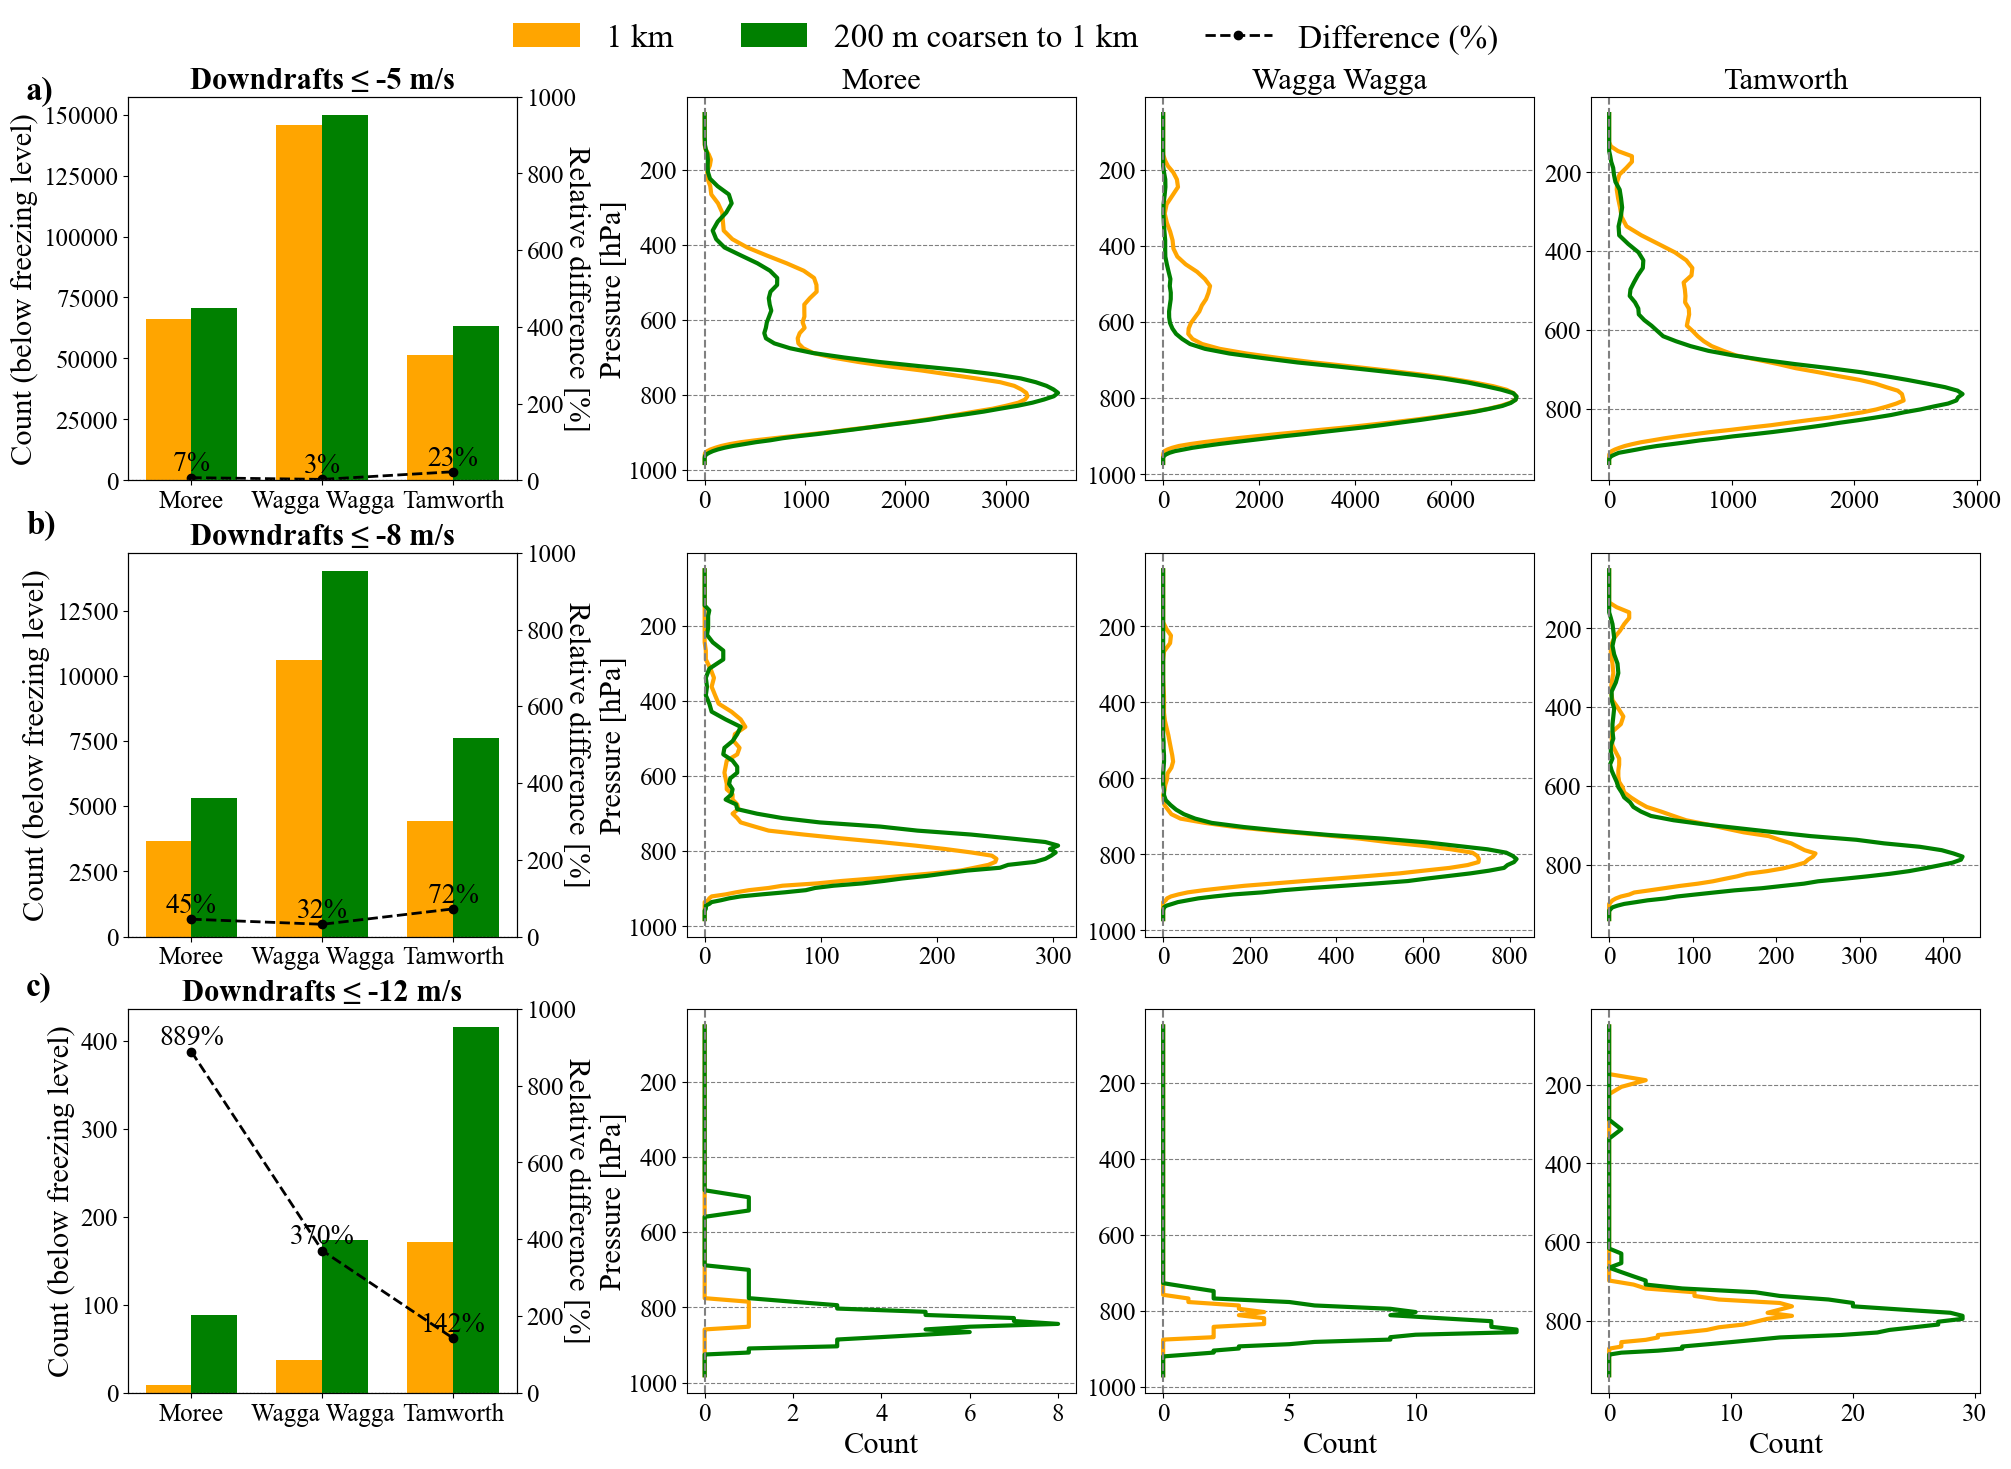

In [25]:
plot_counts_and_profiles(counts_all_down_below, wa_down_strongest_all, thresholds=[-5., -8., -12.])

## Figure 10: Count gusts and updrafts

/jobfs/164324591.gadi-pbs/ipykernel_2440722/1233971654.py:74: RuntimeWarning: divide by zero encountered in divide
  diff = 100 * (lens[:, 1] - lens[:, 0]) / lens[:, 0]
/jobfs/164324591.gadi-pbs/ipykernel_2440722/1233971654.py:74: RuntimeWarning: divide by zero encountered in divide
  diff = 100 * (lens[:, 1] - lens[:, 0]) / lens[:, 0]


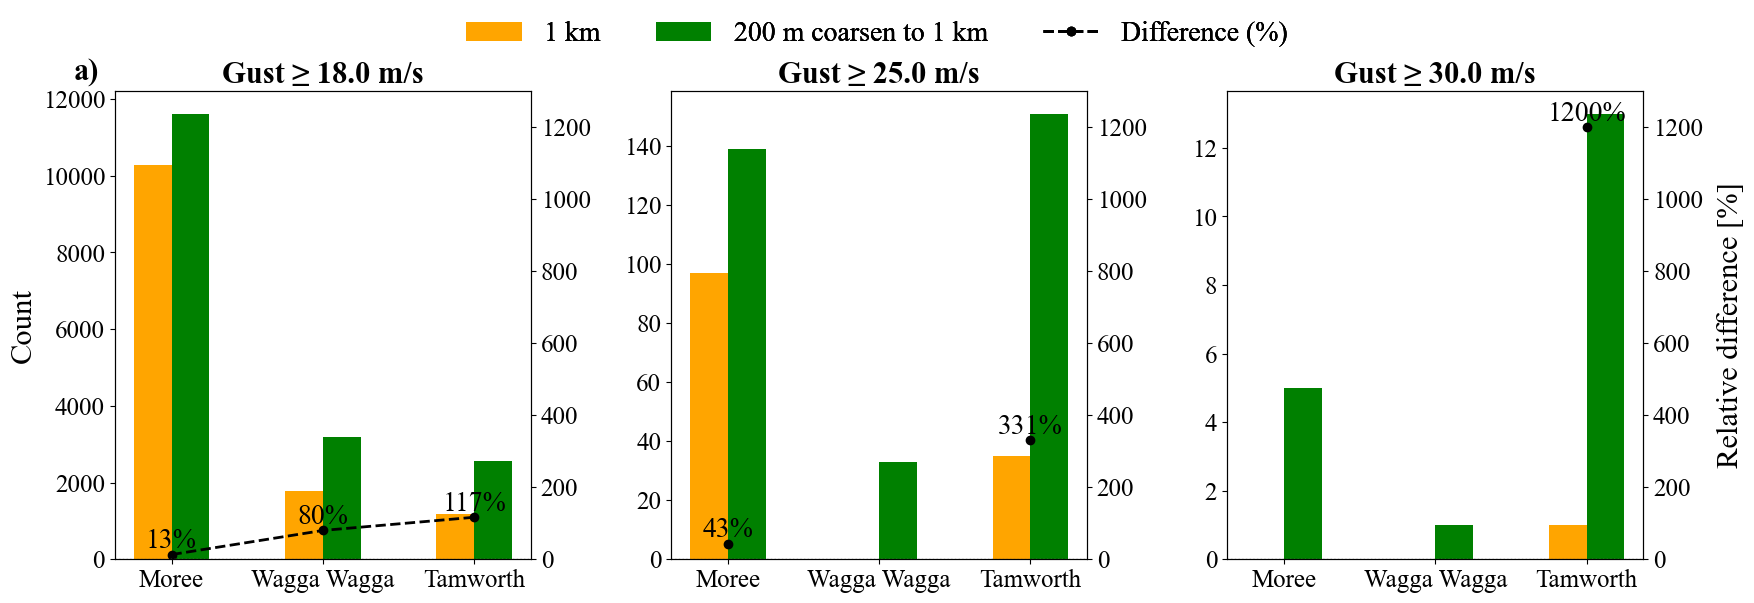

In [27]:
# Total counts Gusts

fs = 22
plt.rcParams.update({
    "font.size": fs,
    "axes.titlesize": fs,
    "axes.labelsize": fs,
    "xtick.labelsize": fs-4,
    "ytick.labelsize": fs-4,
    "legend.fontsize": fs-4,
    "figure.titlesize": fs+2,
    "font.family": "Times New Roman",
})

vars_       = ["WSPD10MAX"] 
hows        = ["All"]
name_vars   = ["Gust"]
unit_vars   = ["m/s"]
thresholdss = [[18., 25., 30.]]
flevels     = [None, None]
labels      = ["a)"]

datasets = ['1 km', '200 m coarsen to 1 km', '200 m original']
colors_  = ["orange", "green", "blue"]
cases    = ['CASE1', 'CASE2_new', 'CASE3_new']
cases1   = ['Moree', 'Wagga Wagga', 'Tamworth']

# --- figure with 3 rows (vars) × 2 columns (max number of thresholds) ---
nrows = len(vars_)
ncols = max(len(th) for th in thresholdss)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(6*ncols, 6*nrows),
                         sharey=False)

if nrows == 1:  # force axes to 2D array
    axes = np.array([axes])
if ncols == 1:
    axes = axes[:, np.newaxis]

for r, (var, how, name_var, unit_var, thresholds, flevel, label) in enumerate(
    zip(vars_, hows, name_vars, unit_vars, thresholdss, flevels, labels)
):
    dic_coarsen = get_dic_filt(var=var, how=how,
                                             thresholds=thresholds, flevel=flevel)

    for c, th_w in enumerate(thresholds):
        ax = axes[r, c]

        lens = []
        for case in cases:
            arr1 = dic_coarsen[f"{var}_{how}_{case}_d02_{th_w}_{flevel}"]
            arr2 = dic_coarsen[f"{var}_{how}_{case}_d03_{th_w}_{flevel}"]
            #arr3 = dic_original[f"{var}_{how}_{case}_d03_{th_w}_{flevel}"]
            lens.append([len(arr1), len(arr2)])
        lens = np.array(lens)

        x = np.arange(len(cases))
        width = 0.25
        for i, dataset in enumerate(datasets[:-1]):  # only 1 km & coarsen
            ax.bar(x + i*width, lens[:, i], width,
                   label=dataset, color=colors_[i])

        ax.set_xticks(x + width/2)
        ax.set_xticklabels(cases1)
        ax.set_title(f"{name_var} ≥ {th_w} {unit_var}", fontweight="bold")

        if c == 0:  # only first col in each row
            ax.set_ylabel("Count")
            ax.text(-0.1, 1.07, label,
                    transform=ax.transAxes, fontsize=fs,
                    fontweight="bold", va="top", ha="left")
            #if r == 0:  # only first row, first col
            #    ax.legend()
        
        # --- Relative difference line ---
        diff = 100 * (lens[:, 1] - lens[:, 0]) / lens[:, 0]
        #diff[np.isinf(diff)] = 0
        
        ax2 = ax.twinx()
        ax2.plot(x + width/2, diff, marker="o", ls="--", color="k", lw=2, label="Difference (%)")
        ax2.axhline(0, color="gray", lw=1, ls=":")
        if c == 2: ax2.set_ylabel("Relative difference [%]", labelpad=10)
        
        # Optional: make both y-axes align nicely
        #ax2.set_ylim(min(-20, diff.min() - 5), max(60, diff.max() + 5))
        ax2.set_ylim(0,1300)
        ax2.yaxis.label.set_color("k")
        ax2.tick_params(axis='y', colors='k')
        
        # --- Optional annotations for clarity ---
        for xi, d in zip(x, diff):
            if d != 0:
                ax2.text(xi + width/2, d + 1, f"{d:.0f}%", ha='center', va='bottom', fontsize=fs-2)

        lines, labels = ax2.get_legend_handles_labels()
        bars, bar_labels = ax.get_legend_handles_labels()
        fig.legend(bars + lines, bar_labels + labels,
                   loc="upper center", ncol=3, frameon=False, fontsize=fs-2, bbox_to_anchor=(0.5, 1.05),)

# clean up empty axes if some rows have fewer thresholds
for r, thresholds in enumerate(thresholdss):
    for c in range(len(thresholds), ncols):
        fig.delaxes(axes[r, c])

plt.tight_layout()
plt.savefig(f"{path_figs}/Figure10_1.png", dpi = 300, bbox_inches = "tight")
plt.show()


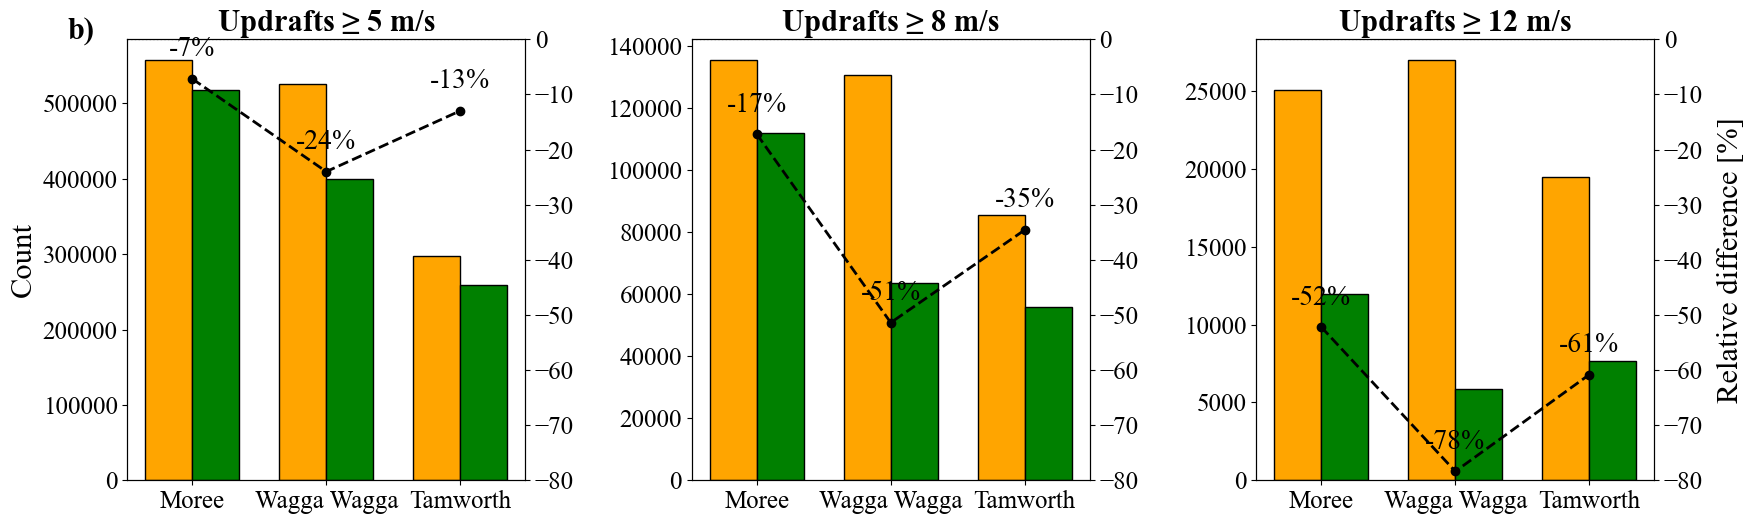

In [28]:
# Total count updrafts

fs = 22
plt.rcParams.update({
    "font.size": fs,
    "axes.titlesize": fs,
    "axes.labelsize": fs,
    "xtick.labelsize": fs-4,
    "ytick.labelsize": fs-4,
    "legend.fontsize": fs-4,
    "figure.titlesize": fs+2,
    "font.family": "Times New Roman",
})

dic_plot = counts_all_up_all
thresholds = [5., 8., 12.]
fig, axes = plt.subplots(1, len(thresholds), figsize=(6*len(thresholds), 6), sharey=False)

datasets = ['1 km', '200 m coarsen']
cases   = ['CASE1', 'CASE2_new', 'CASE3_new']
cases1  = ['Moree', 'Wagga Wagga', 'Tamworth']
datasets = ['1 km', '200 m coarsen to 1 km']
colors_  = ["orange", "green"]
width    = 0.35

for c, thr in enumerate(thresholds):   # c = column index
    stage = "All"
    counts_plot = []
    for case in cases:
        arr1 = dic_plot[thr][f"{case}_d02_coarsen"][f"{case}_d02_{stage}"]
        arr2 = dic_plot[thr][f"{case}_d03_coarsen"][f"{case}_d03_{stage}"]
        counts_plot.append([arr1, arr2])
    counts_plot = np.array(counts_plot)

    ax = axes[c]
    x = np.arange(len(cases))

    # --- Bar plot ---
    for i, dataset in enumerate(datasets):
        ax.bar(x + i*width, counts_plot[:, i], width,
               label=dataset, color=colors_[i], edgecolor="k", linewidth=1)

    ax.set_xticks(x + width/2)
    ax.set_xticklabels(cases1)
    if c == 0:
        ax.set_ylabel("Count")
    ax.set_title(f"Updrafts ≥ {int(thr)} m/s", fontweight="bold")

    # --- Relative difference line ---
    diff = 100 * (counts_plot[:, 1] - counts_plot[:, 0]) / counts_plot[:, 0]

    ax2 = ax.twinx()
    ax2.plot(x + width/2, diff, marker="o", ls="--", color="k", lw=2, label="Difference (%)")
    ax2.axhline(0, color="gray", lw=1, ls=":")
    if c == 2: ax2.set_ylabel("Relative difference [%]", labelpad=10)

    # Optional: make both y-axes align nicely
    #ax2.set_ylim(min(-20, diff.min() - 5), max(60, diff.max() + 5))
    ax2.set_ylim(-80,0)
    ax2.yaxis.label.set_color("k")
    ax2.tick_params(axis='y', colors='k')

    # --- Optional annotations for clarity ---
    for xi, d in zip(x, diff):
        ax2.text(xi + width/2, d + 3, f"{d:.0f}%", ha='center', va='bottom', fontsize=fs-2)

    # --- Label subplot ---
    if c == 0:
        ax.text(-0.15, 1.05, "b)",
                transform=ax.transAxes, fontsize=fs,
                fontweight="bold", va="top", ha="left")

# --- Unified legend for datasets and diff ---
lines, labels = ax2.get_legend_handles_labels()
bars, bar_labels = ax.get_legend_handles_labels()
#fig.legend(bars + lines, bar_labels + labels,
#           loc="upper center", ncol=3, frameon=False, fontsize=fs-2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f"{path_figs}/Figure10_2.png", dpi = 300, bbox_inches = "tight")
plt.show()

## Figure S3: Count other vars

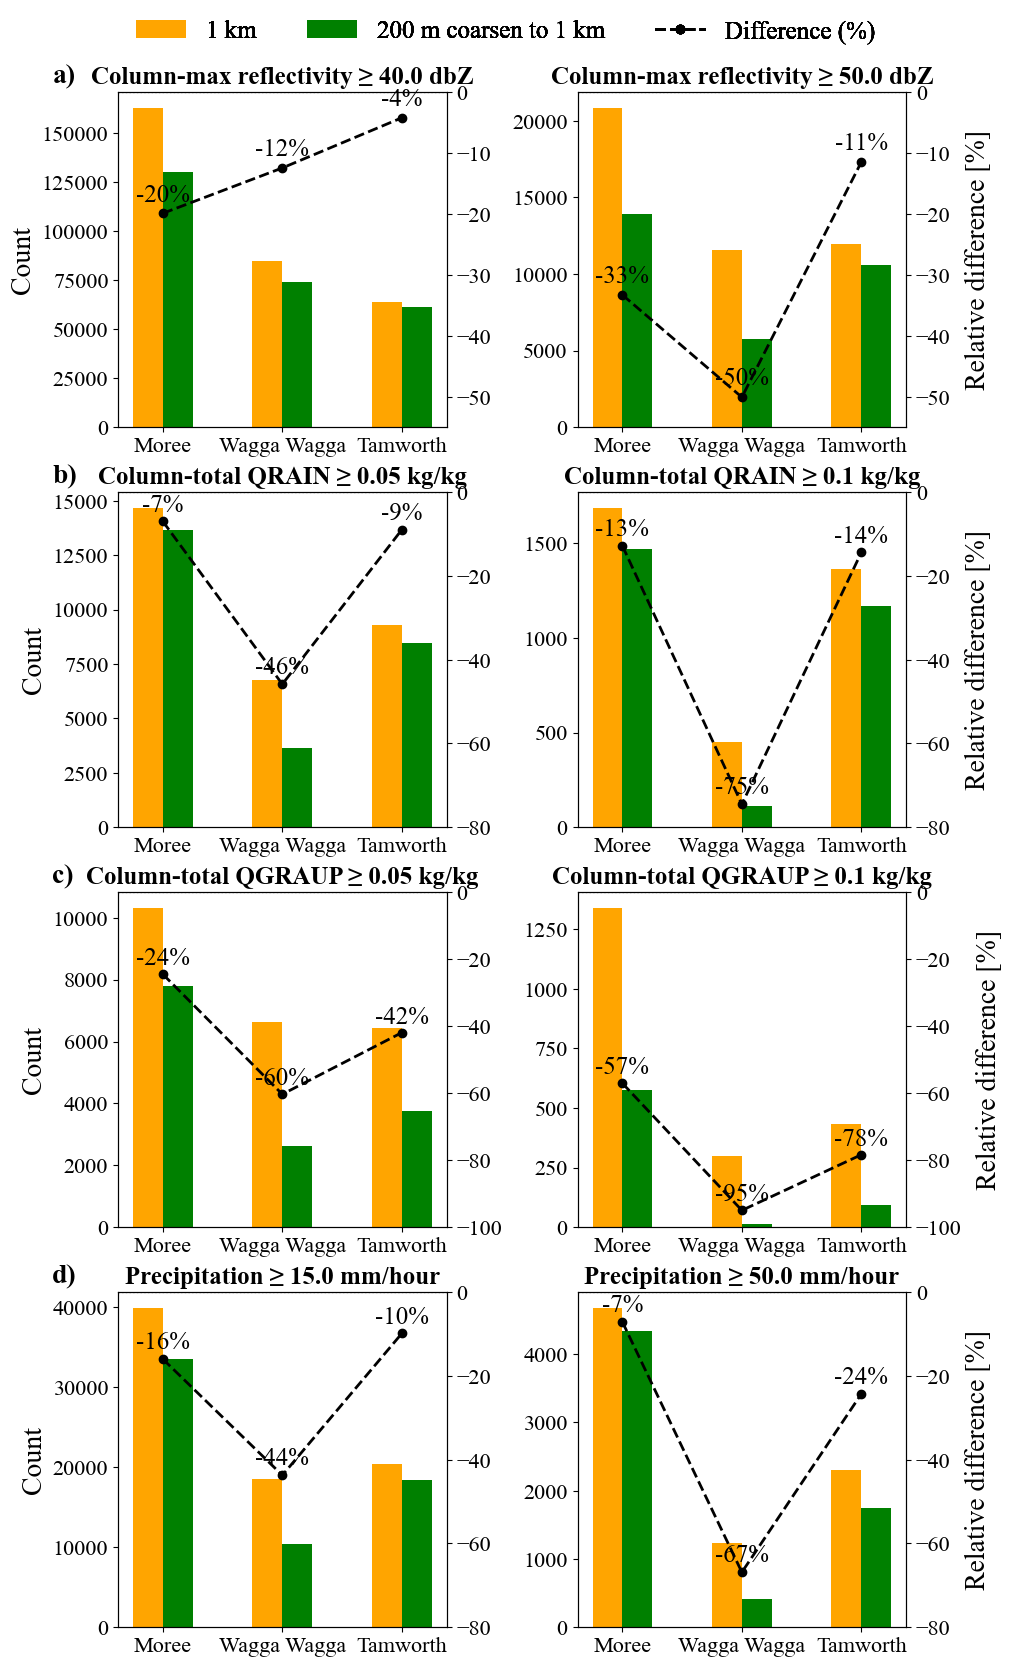

In [31]:
# Count other variables

fs = 20
plt.rcParams.update({
    "font.size": fs,
    "axes.titlesize": fs-2,
    "axes.labelsize": fs,
    "xtick.labelsize": fs-4,
    "ytick.labelsize": fs-4,
    "legend.fontsize": fs-4,
    "figure.titlesize": fs+2,
    "font.family": "Times New Roman",
})

vars_       = ["REFD_MAX", 'QRAIN', 'QGRAUP', "RAINNC"]#[2:]
hows        = ["All", 'sum', 'sum', "All"]#[2:]
name_vars   = ["Column-max reflectivity", "Column-total QRAIN", "Column-total QGRAUP", "Precipitation"]#[2:]
unit_vars   = ["dbZ", "kg/kg", "kg/kg", "mm/hour"]#[2:]
thresholdss = [[40., 50.], [0.05, 0.1], [0.05, 0.1], [15., 50.]]#[2:]
flevels     = [None, None, None, None]#[2:]
labels      = ["a)", "b)", "c)", "d)"]#[2:]

datasets = ['1 km', '200 m coarsen to 1 km']
colors_  = ["orange", "green", "blue"]
cases    = ['CASE1', 'CASE2_new', 'CASE3_new']
cases1   = ['Moree', 'Wagga Wagga', 'Tamworth']

# --- figure with 3 rows (vars) × 2 columns (max number of thresholds) ---
nrows = len(vars_)
ncols = max(len(th) for th in thresholdss)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(5*ncols, 4*nrows),
                         sharey=False, constrained_layout=True)

if nrows == 1:  # force axes to 2D array
    axes = np.array([axes])
if ncols == 1:
    axes = axes[:, np.newaxis]

for r, (var, how, name_var, unit_var, thresholds, flevel, label) in enumerate(
    zip(vars_, hows, name_vars, unit_vars, thresholdss, flevels, labels)
):
    dic_coarsen = get_dic_filt(var=var, how=how,thresholds=thresholds, flevel=flevel)

    for c, th_w in enumerate(thresholds):
        ax = axes[r, c]

        lens = []
        for case in cases:
            arr1 = dic_coarsen[f"{var}_{how}_{case}_d02_{th_w}_{flevel}"]
            arr2 = dic_coarsen[f"{var}_{how}_{case}_d03_{th_w}_{flevel}"]
            lens.append([len(arr1), len(arr2)])
        lens = np.array(lens)

        x = np.arange(len(cases))
        width = 0.25
        for i, dataset in enumerate(datasets):  # only 1 km & coarsen
            ax.bar(x + i*width, lens[:, i], width,
                   label=dataset, color=colors_[i])

        ax.set_xticks(x + width/2)
        ax.set_xticklabels(cases1)
        ax.set_title(f"{name_var} ≥ {th_w} {unit_var}", fontweight="bold")

        if c == 0:  
            ax.set_ylabel("Count")
            ax.text(-0.2, 1.08, label,
                    transform=ax.transAxes, fontsize=fs,
                    fontweight="bold", va="top", ha="left")
                
        diff = 100 * (lens[:, 1] - lens[:, 0]) / lens[:, 0]
        
        ax2 = ax.twinx()
        ax2.plot(x + width/2, diff, marker="o", ls="--", color="k", lw=2, label="Difference (%)")
        ax2.axhline(0, color="gray", lw=1, ls=":")
        if c == 1: ax2.set_ylabel("Relative difference [%]", labelpad=10)
        
        # Optional: make both y-axes align nicely
        #ax2.set_ylim(min(-20, diff.min() - 5), max(60, diff.max() + 5))
        if var == "REFD_MAX":
            ax2.set_ylim(-55,0)
        elif var == 'QRAIN':
            ax2.set_ylim(-80,0)
        elif var == 'QGRAUP':
            ax2.set_ylim(-100,0)
        else: #"RAINNC"
            ax2.set_ylim(-80,0)
        
        ax2.yaxis.label.set_color("k")
        ax2.tick_params(axis='y', colors='k')
        
        # --- Optional annotations for clarity ---
        for xi, d in zip(x, diff):
            if d != 0:
                ax2.text((xi + width/2), d + 1, f"{d:.0f}%", ha='center', va='bottom', fontsize=fs-2)

        lines, labels = ax2.get_legend_handles_labels()
        bars, bar_labels = ax.get_legend_handles_labels()
        fig.legend(bars + lines, bar_labels + labels,
                   loc="upper center", ncol=3, frameon=False, fontsize=fs-2, bbox_to_anchor=(0.5, 1.04),)


# clean up empty axes if some rows have fewer thresholds
for r, thresholds in enumerate(thresholdss):
    for c in range(len(thresholds), ncols):
        fig.delaxes(axes[r, c])

plt.savefig(f"{path_figs}/FigureS3.png", dpi = 300, bbox_inches = "tight")
plt.show()

## Figure S4: Updrafts all levels

In [33]:
def plot_counts_and_profiles_up(counts_all, dic_wa, thresholds=[5., 8., 12.]):
     """""""""""""""""""""""""""""""""""""""""""""""""""
    # Plot counts and profiles: 1 km versus 200 m: for updrafts
    """""""""""""""""""""""""""""""""""""""""""""""""""

    # Font settings
    fs = 20
    plt.rcParams.update({
        "font.size": fs,
        "axes.titlesize": fs,
        "axes.labelsize": fs,
        "xtick.labelsize": fs-4,
        "ytick.labelsize": fs-4,
        "legend.fontsize": fs-4,
        "figure.titlesize": fs+2,
        "font.family": "Times New Roman",
    })
    
    # Config
    cases   = ['CASE1', 'CASE2_new', 'CASE3_new']
    cases1  = ['Moree', 'Wagga Wagga', 'Tamworth']
    datasets = ['1 km', '200 m coarsen to 1 km']
    colors_  = ["orange", "green"]
    width    = 0.35
    
    # Grid: 3 thresholds × (1 bar + 3 profiles = 4 columns)
    fig, axes = plt.subplots(
        nrows=len(thresholds), ncols=4, figsize=(20, 14), sharey=False, constrained_layout=True
    )

    # Loop thresholds (rows)
    for r, thr in enumerate(thresholds):
        ## ----- Column 1: bar plot of total counts -----
        stage = "All"
        counts_plot = []
        for case in cases:
            arr1 = counts_all[thr][f"{case}_d02_coarsen"][f"{case}_d02_{stage}"]
            arr2 = counts_all[thr][f"{case}_d03_coarsen"][f"{case}_d03_{stage}"]
            counts_plot.append([arr1, arr2])
        counts_plot = np.array(counts_plot)

        ax1 = axes[r, 0]
        x = np.arange(len(cases))
        for i, dataset in enumerate(datasets):
            ax1.bar(x + i*width, counts_plot[:, i], width,
                    label=dataset, color=colors_[i])
        ax1.set_xticks(x + width/2)
        ax1.set_xticklabels(cases1)
        ax1.set_ylabel("Count (below freezing level)")
        ax1.set_title(f"Updrafts >= {int(thr)} m/s", fontweight = "bold")

        # --- Relative difference line ---
        diff = 100 * (counts_plot[:, 1] - counts_plot[:, 0]) / counts_plot[:, 0]
        
        ax2 = ax1.twinx()
        ax2.plot(x + width/2, diff, marker="o", ls="--", color="k", lw=2, label="Difference (%)")
        ax2.axhline(0, color="gray", lw=1, ls=":")
        ax2.set_ylabel("Relative difference [%]", labelpad=10, rotation=270)
        
        # Optional: make both y-axes align nicely
        ax2.set_ylim(-30,30)
        ax2.yaxis.label.set_color("k")
        ax2.tick_params(axis='y', colors='k')
        
        # --- Optional annotations for clarity ---
        for xi, d in zip(x, diff):
            ax2.text(xi + width/2, d + 1, f"{d:.0f}%", ha='center', va='bottom', fontsize=fs-2)

        lines, labels = ax2.get_legend_handles_labels()
        bars, bar_labels = ax1.get_legend_handles_labels()
    
        ## ----- Columns 2–4: vertical distributions per case -----
        for c, case in enumerate(cases):
            ax2 = axes[r, c+1]   # shift by +1 since col0 is bar plot
            for dom, name in zip(domains, ["1 km", "200 m coarsen to 1 km"]):
                height_meanprof = prof_coarsen_all["All"][f"pressure_{case}_{dom}"]
                wa_strong = dic_wa[f'{case}_{dom}_coarsen'][f'{case}_{dom}_All']
                wa_strong_masked = np.where(wa_strong >= thr, wa_strong, np.NaN)
                counts_strong = np.sum(~np.isnan(wa_strong_masked), axis=(0,2,3))
                ax2.plot(counts_strong, height_meanprof, 
                         label=f"{name}",
                         lw=3.0,
                         color="green" if dom == "d03" else "orange")
            ax2.invert_yaxis()
            ax2.axvline(x=0, ls="--", color="grey")
            ax2.grid(axis = "y", ls = "--", c = "grey")
            if r == 0:
                ax2.set_title(cases1[c])
            if c == 0:
                ax2.set_ylabel("Pressure [hPa]", labelpad=0.)
            if r == len(thresholds)-1:
                ax2.set_xlabel("Count")
            #if r == 0 and c == 0:
            #    ax2.legend(frameon=False, loc = 1)

    # Example: manually set label positions
    panel_labels = ["a)", "b)", "c)"]
    label_x = 0.03       # horizontal position in figure coordinates (0 = left, 1 = right)
    label_ys = [0.96, 0.65, 0.32]  # vertical positions for each row (top to bottom)
    
    for r, thr in enumerate(thresholds):
        panel_label = panel_labels[r]
        fig.text(label_x-0.02, label_ys[r]+0.02, panel_label, va="center", ha="left", 
                 fontsize=fs+2, fontweight="bold")


    fig.legend(bars + lines, bar_labels + labels,
               loc="upper center", ncol=3, frameon=False, fontsize=fs+1, bbox_to_anchor=(0.5, 1.05))

    plt.savefig(f"{path_figs}/FigureS4.png", dpi = 300, bbox_inches = "tight")
    plt.show()

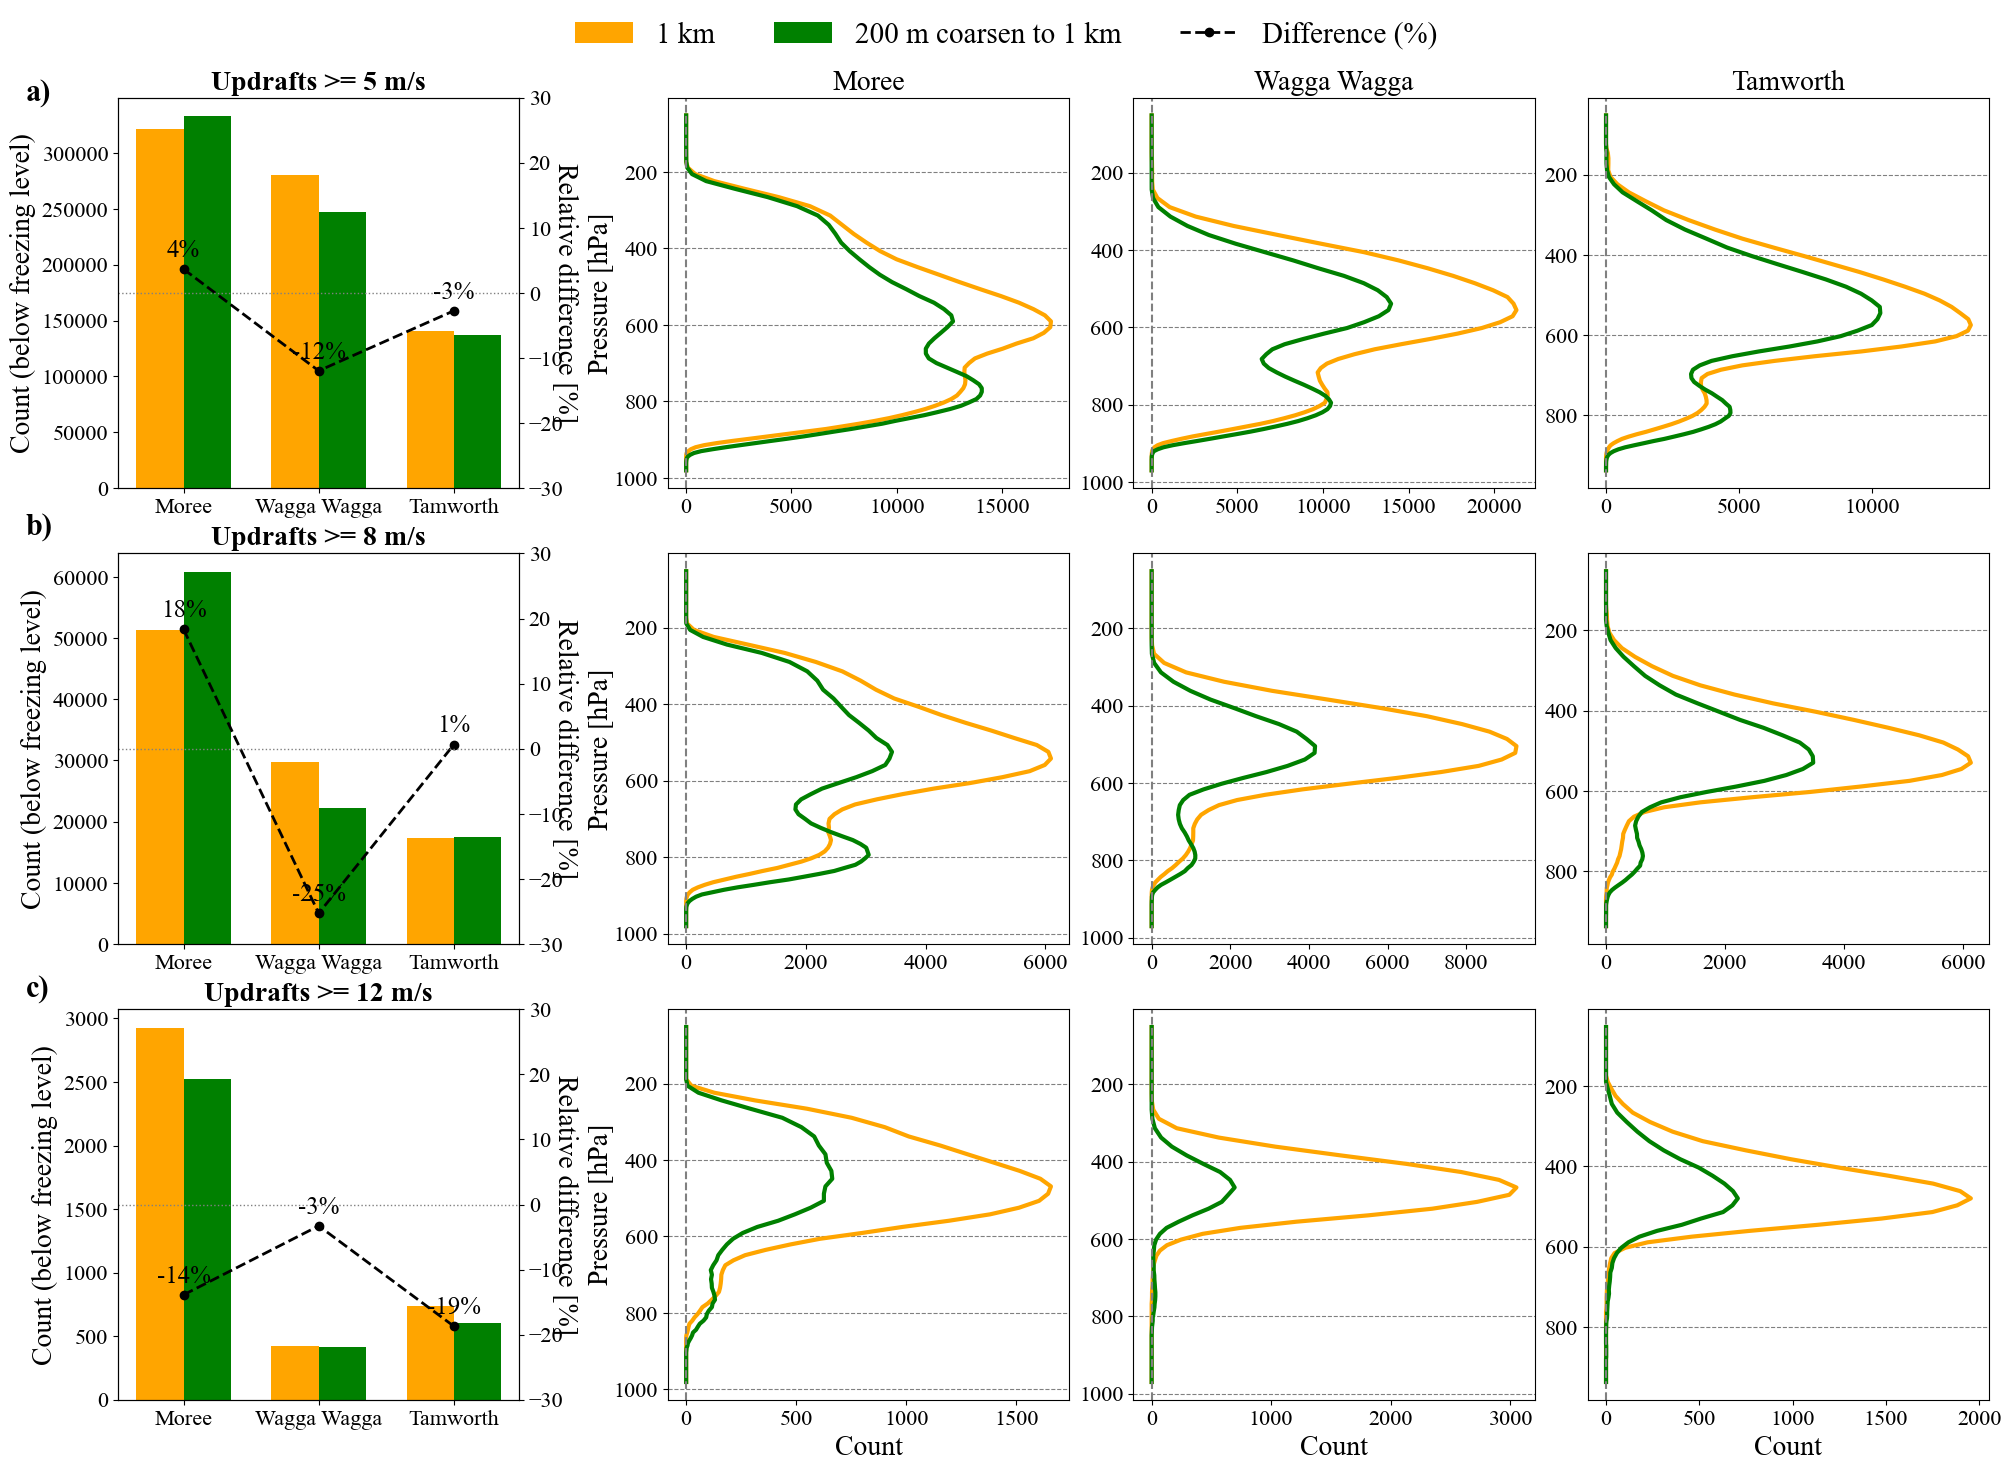

In [34]:
plot_counts_and_profiles_up(counts_all_up_below, wa_up_strongest_all, thresholds=[5., 8., 12.])